In [1]:
from networks.BP_network import *
from networks.EWC_network import *
from networks.DFC_network import *
from networks.EFC_network import *
from src.dataloaders import *
from src.trainers import Trainer, TrainerDFCL, TrainerDFCGen
from src.utils import *
import matplotlib.animation as animation
from networks.activation_function import ScaledSigmoid

/cluster/raid/home/sschwartz/.conda/envs/DFC_project/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
config = {
        "layers": [784, 200, 200, 10],
        "num_classes": 10,
        "lr": 1e-4, 
        "lr_fb": 1e-4, 
        "batch_size": 100,
        "batch_size_gen": 30000,
        "epochs": 20,
        "mode": "di",
        "num_workers": 0,
        "loss_fn": "ce",
        "optimizer": "Adam",
        "scheduler": "CosineAnnealingLR",
        "activation_fun": "Tanh",
        "device": "cuda",
        "output_dir": "./outputs",
        "seed": 1337,
        "taus": [0.02, 0.02, 0.02, 0.016, 0.01],
        "target_lr": 1,#1e-2,       # Updated to optimal value
        "alpha_di": 0.0017,        # 1/tau for tau=0.2
        "dt_di": 0.02,         # Time step
        "time_constant_ratio": 0.2,  # tau
        "tmax_di":3,
        "k_p": 2.0,             # Optimal for G=1, tau=0.2
        "eps": 1e-4,
        "save": True,
        "flatten_imgs": "default",
        "num_tasks": 2,
        "classes_per_task": 5,
        "setting": "full",
        "first_task_only": False,
}

config = dotdict(config)

In [3]:
# Load data
train_loader, test_loader = MNIST(config=config).get_dataloaders()

In [4]:
# Train model
model = DFCL_network_multilayer(config=config)

trainer = TrainerDFCL(model, train_loader, test_loader, config)
trainer.train()

[DFCL] Feedback connections initialized.
Training:
 - layers: [784, 200, 200, 10]
 - num_classes: 10
 - lr: 0.0001
 - lr_fb: 0.0001
 - batch_size: 100
 - batch_size_gen: 30000
 - epochs: 20
 - mode: di
 - num_workers: 0
 - loss_fn: ce
 - optimizer: Adam
 - scheduler: CosineAnnealingLR
 - activation_fun: Tanh
 - device: cuda
 - output_dir: ./outputs
 - seed: 1337
 - taus: [0.02, 0.02, 0.02, 0.016, 0.01]
 - target_lr: 1
 - alpha_di: 0.0017
 - dt_di: 0.02
 - time_constant_ratio: 0.2
 - tmax_di: 3
 - k_p: 2.0
 - eps: 0.0001
 - save: True
 - flatten_imgs: default
 - num_tasks: 2
 - classes_per_task: 5
 - setting: full
 - first_task_only: False
 - in_channels: 1
 - model: DFCL_network

[TrainerDFCL] Created optimizers: feedforward, 1× feedback.


				Epoch: 001, Train loss: 1.5259 & test loss: 0.7052 & accuracy: 82.20


				Epoch: 002, Train loss: 0.5239 & test loss: 0.3931 & accuracy: 89.38


				Epoch: 003, Train loss: 0.3604 & test loss: 0.3115 & accuracy: 91.12


				Epoch: 004, Train loss: 0.3019 & test loss: 0.2735 & accuracy: 92.18


...

				Epoch: 016, Train loss: 0.1238 & test loss: 0.1312 & accuracy: 96.01


				Epoch: 017, Train loss: 0.1181 & test loss: 0.1277 & accuracy: 96.27


				Epoch: 018, Train loss: 0.1131 & test loss: 0.1228 & accuracy: 96.30


				Epoch: 019, Train loss: 0.1081 & test loss: 0.1193 & accuracy: 96.40


				Epoch: 020, Train loss: 0.1035 & test loss: 0.1167 & accuracy: 96.46


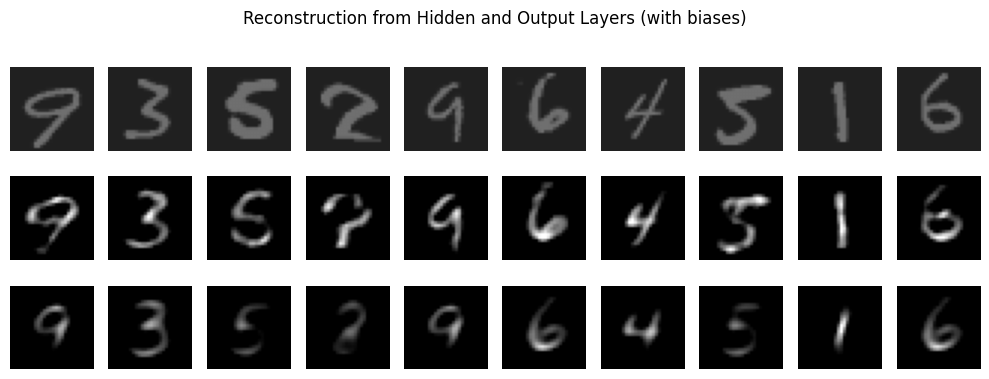

In [17]:
x1, x2, x3 = visualize_reconstructions(model, train_loader)

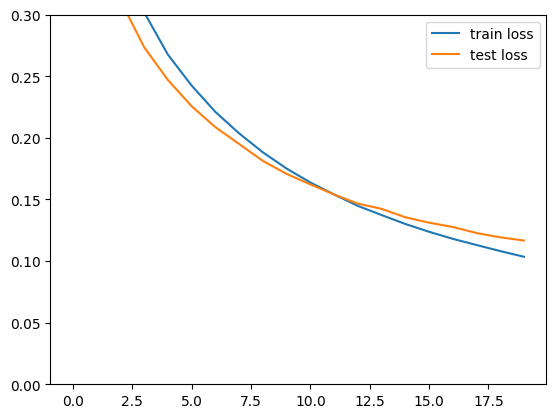

In [6]:
plt.plot(model.train_loss_hist, label="train loss")
plt.plot(model.test_loss_hist, label="test loss")
plt.legend()
plt.ylim([0,0.3])
plt.show()

In [5]:
model = DFCL_network(config)

# Load the trained weights
checkpoint = torch.load("/cluster/raid/home/sschwartz/Equilibrium-Fisher-Control/outputs/DFCL_network_lr0.0001_01-12_10-48-17/model.pt", map_location=torch.device(config.device))
model.load_state_dict(checkpoint)

# Set model to evaluation mode
model.eval()

print("Loaded DFC_network successfully!")

[DFCL] Lateral connections initialized.
[DFCL] Feedback connections initialized.
Loaded DFC_network successfully!


In [7]:
(train_loss, train_acc), (test_loss, test_acc) = evaluate(model, train_loader, test_loader, device=model.device)

Train loss: 0.0032 | Train acc: 99.99%
Test  loss: 0.0992 | Test  acc: 97.32%


In [7]:
pixel_mean, pixel_std = compute_mnist_pixel_stats()

In [58]:
@torch.no_grad()
def generate_samples(model, target_activity, init_input=None, batch_size=10, tmax=500, pixel_std=None, pixel_mean=None, threshold=0.001):
    """
    Generate samples by running DFC dynamics in reverse.
    
    Args:
        model: trained DFC_network instance.
        target_activity: desired target output (batch_size x output_size)
        init_input: optional initial input tensor (batch_size x input_size)
    
    Returns:
        generated_inputs: steady-state input representations that evoke the target activity.
    """
    # === Setup ===
    model.targets = target_activity
    model.bzs = target_activity.shape[0]
    scaled_sig = ScaledSigmoid()


    # Initialize input (random if none provided)
    if init_input is None:
        init_input_scaled = (torch.randn(batch_size, 28*28, device=model.device)* pixel_std.flatten().to(model.device) + pixel_mean.flatten().to(model.device))
        input_pre = init_input_scaled
        model.input = input_pre
    else:
        init_input_scaled = init_input.to(model.device)
        input_pre = init_input_scaled
        model.input = input_pre

    layer_out_dims = [layer.weights.shape[0] for layer in model.layers]

    v_fb_current = [torch.zeros((model.bzs, lod), device=model.device) for lod in layer_out_dims]
    v_ff_current = [torch.zeros((model.bzs, lod), device=model.device) for lod in layer_out_dims]
    v_current = [torch.zeros((model.bzs, lod), device=model.device) for lod in layer_out_dims]
    r_current = [torch.zeros((model.bzs, lod), device=model.device) for lod in layer_out_dims]
    u_current = torch.zeros((model.bzs, model.layer_sizes[-1]), device=model.device)
    u_int_current = torch.zeros_like(u_current)

    u_current2 = torch.zeros((model.bzs, model.layer_sizes[-2]), device=model.device)
    u_int_current2 = torch.zeros_like(u_current2)

    # Forward init
    with torch.no_grad():
        r_prev = model.input
        for i, layer in enumerate(model.layers):
            v_ff_current[i] = r_prev.mm(layer.weights.t()) + layer.bias.unsqueeze(0)
            v_current[i] = v_ff_current[i]
            r_current[i] = layer.activation_fn(v_ff_current[i])
            r_prev = r_current[i]
    _ = model(model.input)


    converged_mask = torch.zeros((model.bzs,), dtype=torch.bool, device=model.device)
    converged_time = torch.zeros((model.bzs,), dtype=torch.int, device=model.device)

    diffs = []
    diffs2 = []
    


    video = [model.input[0].clone()]
    printed = False
    # === Dynamics ===
    for t in range(tmax - 1):
        """if converged_mask.all():
            if not printed:
                print(t)
                printed=True
            break"""

        
        error = model._compute_error(r_current[-1], model.targets)

        # PI control
        u_int_next = u_int_current + model.dt * (error - model.alpha * u_current)
        u_next = u_int_next + model.k_p * error


        converged_mask = (torch.abs(error)).mean(dim=1) < threshold ### careful here
        converged_time += converged_mask*t*(converged_time==0)


        #_, Js = model._calculate_full_jacobian()

        for i, layer in enumerate(model.layers):
            r_prev = r_current[i - 1] if i != 0 else model.input

            # Basal + apical feedback
            v_ff_current[i] += (r_prev.mm(layer.weights.t()) + layer.bias.unsqueeze(0) - v_ff_current[i]) 
            v_ff_current[i] = v_ff_current[i].clone().detach()
            

            tau = model.dt / model.time_constant_ratio

            if i!=len(model.layers)-1:
                v_fb_current[i] =  (model.feedback_layers[i+1](u_next)) * layer.activation_derivative(v_current[i])
                v_current[i] += tau * (v_fb_current[i] * (~converged_mask.unsqueeze(1))+ v_ff_current[i] - v_current[i])* (~converged_mask.unsqueeze(1))
            else:
                #v_fb_current[i] = torch.bmm(Js[i].transpose(1, 2), u_next.unsqueeze(2)).squeeze(2)
                #v_current[i] += tau * (v_fb_current[i] + v_ff_current[i] - v_current[i]) * (~converged_mask.unsqueeze(1))
                v_current[i] +=  tau * (v_ff_current[i] - v_current[i]) * (~converged_mask.unsqueeze(1))
                #v_current[i] += (v_ff_current[i] - v_current[i]) * (~converged_mask.unsqueeze(1)) 


            r_current[i] = layer.activation_fn(v_current[i])


            layer.v_ff = v_current[i]
            layer.r = r_current[i]

        error2 = model._compute_error_mse(model.layers[0].activation_fn(v_ff_current[0]), r_current[-2])

        # PI control
        u_int_next2 = u_int_current2 + model.dt * (error2 - model.alpha * u_current2)
        u_next2 = u_int_next2 + model.k_p * error2

        u_int_current = u_int_next
        u_current = u_next

        u_int_current2 = u_int_next2
        u_current2 = u_next2


        
        grad_input = torch.sigmoid(model.feedback_layers[0](r_current[-2]))
        #grad_input = torch.clamp(grad_input, -0.4242 ,2.8215)
        #grad_input += torch.sigmoid(model.feedback_layers[0](u_next2))



        model.input += tau* (grad_input-model.input) 
        #model.input = torch.clamp(model.input, -0.4242 ,2.8215)
        model.input = torch.clamp(model.input, 0 ,1)
        
        
        video.append(torch.sigmoid(model.feedback_layers[0](r_current[0]))[0].clone())
        diff = torch.abs(r_current[0] - model.layers[0].activation_fn(model.layers[0](model.input))).mean().detach().cpu().numpy()
        diffs.append(diff)
        diff2 = torch.abs(r_current[1] - model.layers[1].activation_fn(model.layers[1](r_current[0]))).mean().detach().cpu().numpy()
        diffs2.append(diff2)

    # === Collect steady-state representations ===
    rs = [model.input]
    for i, layer in enumerate(model.layers):
        layer.r = r_current[i]
        layer.r_ff = layer.activation_fn(v_ff_current[i])
        layer.r_prev = rs[i]
        rs.append(r_current[i])

    print(converged_mask.sum())


    generated_inputs = model.input
    #generated_inputs = torch.clamp(generated_inputs, 0, 1)

    
    print(diff)
    
    return generated_inputs, rs, video, diffs, diffs2, converged_time


In [59]:
batch_size = 100
num_classes = 10

# Create one-hot targets for classes 0..9
target = torch.eye(num_classes).repeat_interleave(int(batch_size/10), dim=0)
#target = random_smooth_labels(targets=target.argmax(dim=1))


generated_input, rs, video, diffs,diffs2, converged_time = generate_samples(model, target, batch_size=batch_size, tmax=5000, pixel_mean=pixel_mean, pixel_std=pixel_std, threshold=0.001)
print((target.argmax(dim=1)==rs[-1].argmax(dim=1)).sum())
print((target.argmax(dim=1)== model(generated_input).argmax(dim=1)).sum())

tensor(100, device='cuda:0')
0.20072958
tensor(100, device='cuda:0')
tensor(50, device='cuda:0')


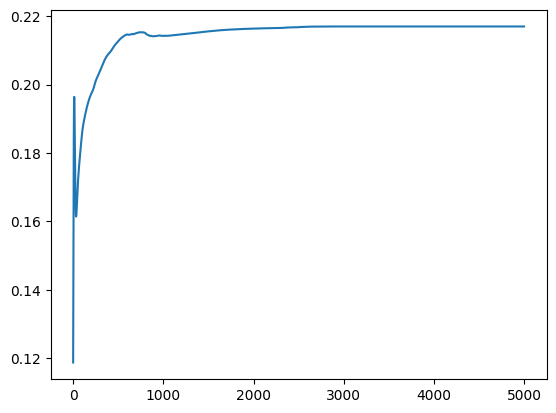

In [61]:
plt.plot(diffs2)

In [13]:
batch_size = 100
num_classes = 10

Xs = []   
Ys = []
Y_preds = []

for batch in train_loader:
    ypred = model(batch[0].to(model.device))
    B, K = ypred.shape
    K = 11

    # argmax indices
    top1 = batch[1].argmax(dim=1).to(model.device)  # (B,)
    # sample random classes
    rand = torch.randint(0, K - 1, (B,), device=ypred.device) 
    # shift to skip argmax
    rand = rand + (rand >= top1).long()

    #target = torch.eye(5).repeat_interleave(20, dim=0)
    #target = random_smooth_labels(targets=rand)
    #target = F.one_hot(torch.tensor(rand), num_classes=10).long()
    #target = F.one_hot(torch.tensor(ypred.argmax(dim=1)), num_classes=10).long()
    #Y_preds.append(target)
    
    Xs.append(batch[0])
    Ys.append(batch[1])   
    if batch_size==100:
        break

X = torch.cat(Xs, dim=0)
Y = torch.cat(Ys, dim=0)
Y_label = torch.argmax(Y,dim=1)
#target = torch.cat(Y_preds,dim=0)

print("random targets generated ...")


generated_input, rs, video, diffs, converged_time = generate_samples(model, target, batch_size=batch_size, init_input=X.to(model.device), tmax=2000, threshold=0.001)


random targets generated ...
tensor(46, device='cuda:0')
0.21920028


In [ ]:
batch_size = 100
num_classes = 10

K = 11

init_input = torch.clamp(torch.randn(batch_size, 200, device=model.device),-0.5,0.5)
#init_input = 2 * torch.rand(batch_size, 200, device=model.device) - 1
init_input = torch.clamp(model.feedback_layers[0](init_input), -0.4242, 2.8215)

# sample random classes
rand = torch.randint(0, K - 1, (batch_size,), device=model.device)
target = F.one_hot(torch.tensor(rand), num_classes=10)
#target = torch.eye(10).repeat_interleave(int(batch_size/10), dim=0)

generated_input, rs, video, diffs, converged_time = generate_samples(model, target, init_input=init_input, batch_size=batch_size, tmax=5000, pixel_mean=pixel_mean, pixel_std=pixel_std, threshold=0.0001)
print((target.argmax(dim=1)==rs[-1].argmax(dim=1)).sum())
print((target.argmax(dim=1)== model(generated_input).argmax(dim=1)).sum())

In [11]:
batch_size = 100
num_classes = 10

K = 11

init_input = torch.clamp(torch.randn(batch_size, 200, device=model.device),-1,1)
#init_input = 2 * torch.rand(batch_size, 200, device=model.device) - 1
init_input = torch.clamp(model.feedback_layers[0](init_input), -0.4242, 2.8215)

# sample random classes
rand = torch.randint(0, K - 1, (batch_size,), device=model.device)
target = F.one_hot(torch.tensor(rand), num_classes=10)
#target = torch.eye(10).repeat_interleave(int(batch_size/10), dim=0)

generated_input, rs_last, diffs = model.generate_samples(target, init_input=init_input, tmax=5000, threshold=0.0001)

/cluster/raid/home/sschwartz/.conda/envs/DFC_project/lib/python3.11/site-packages/torch/utils/_device.py:109: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)


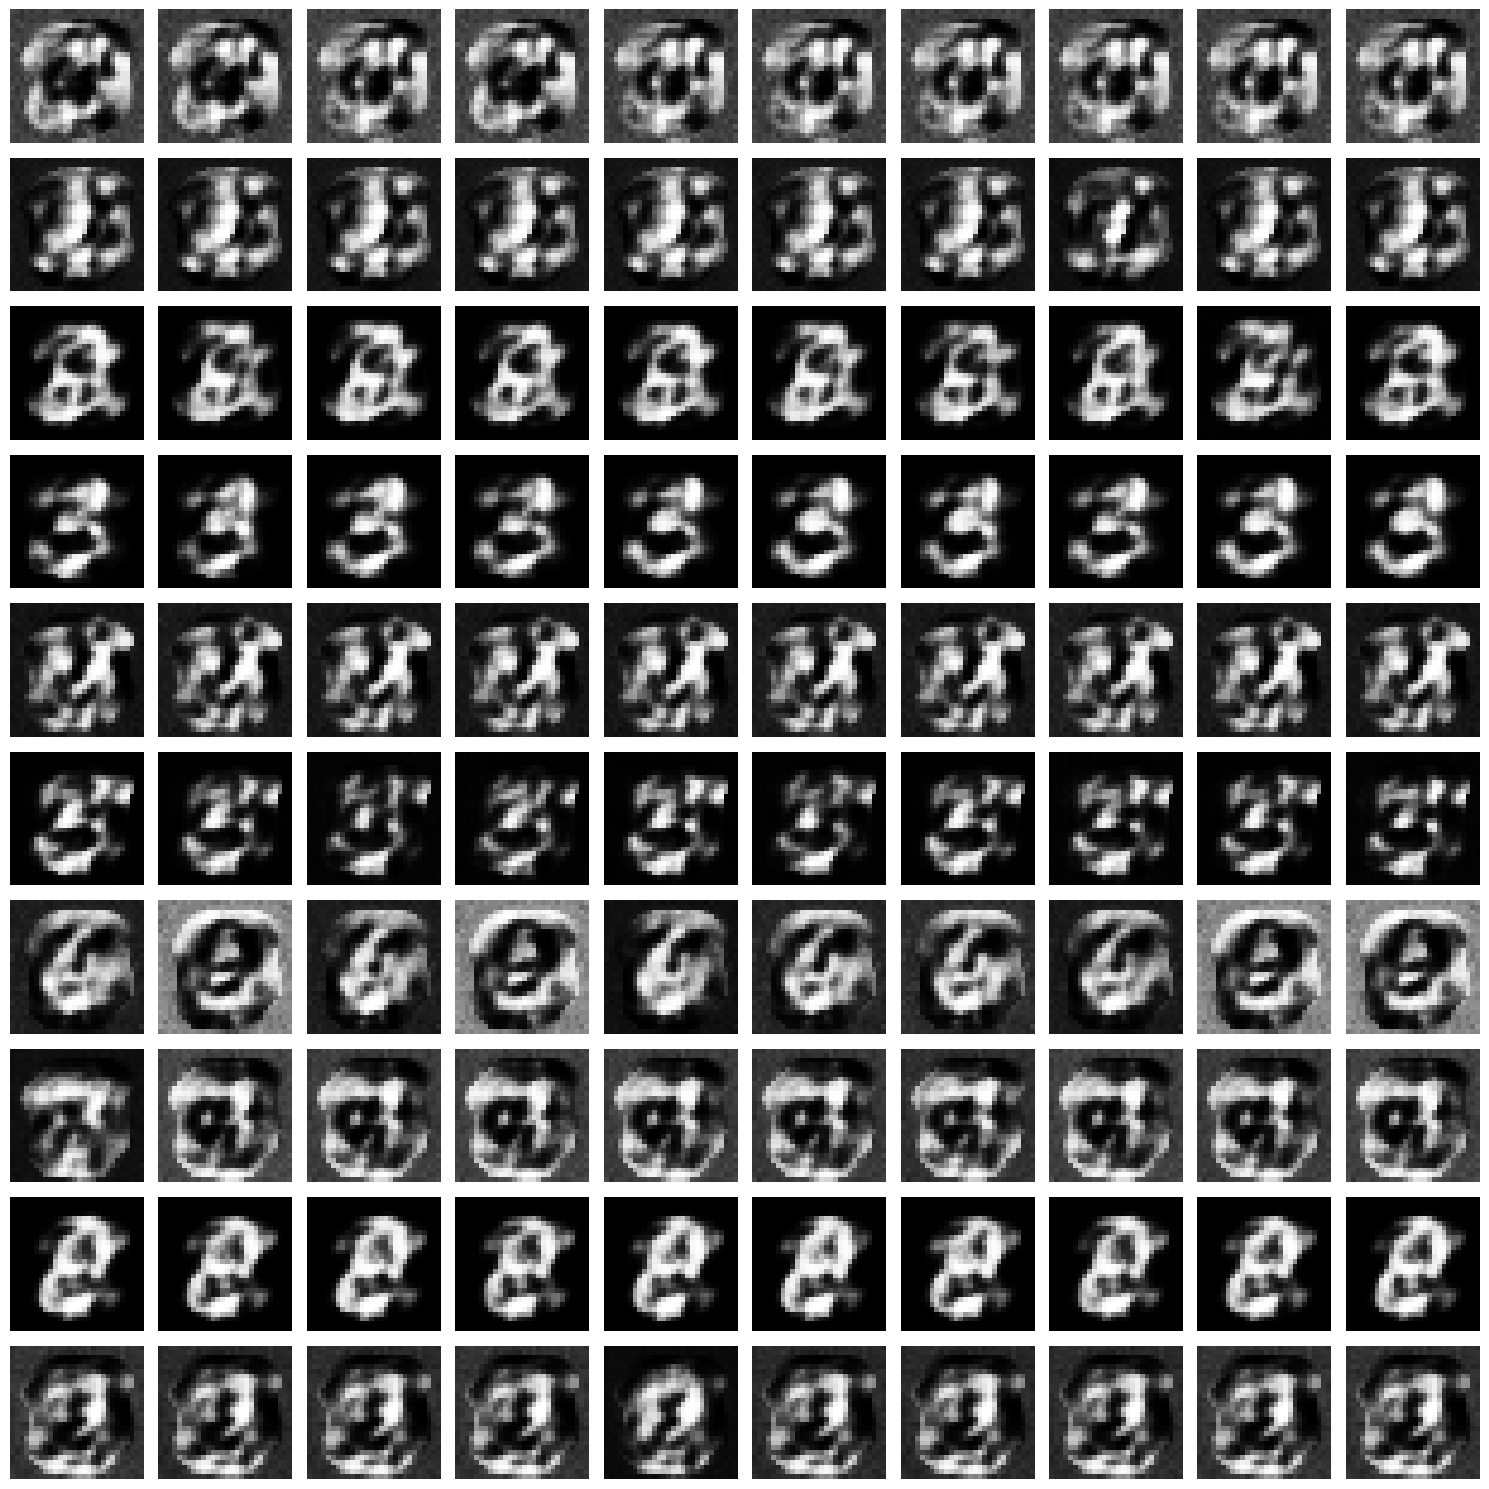

In [53]:
imgs = generated_input.detach().cpu()
n_cols=10

# Normalize to [0, 1] for display
#imgs = (imgs - imgs.min()) / (imgs.max() - imgs.min() + 1e-8)

# Try to infer image dimensions (e.g. 28x28 for MNIST)
img_size = int(imgs.shape[1] ** 0.5)
imgs = imgs.view(-1, img_size, img_size)

n_samples = imgs.shape[0]
n_rows = (n_samples + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 1.5, n_rows * 1.5))
for i in range(n_samples):
    plt.subplot(n_rows, n_cols, i + 1)
    #plt.imshow(imgs[i], cmap="gray", vmin=0.0, vmax=1.0)
    plt.imshow(imgs[i], cmap="gray")
    plt.axis("off")

plt.tight_layout()

plt.show()


In [ ]:
plot_generated_inputs(generated_input[:100], n_cols=10, title="Sample Generation Input", save=False, filename="Samples_BP_100_epochs.png")

In [16]:
from torch.distributions import Dirichlet

def random_smooth_labels(targets, num_classes=10, alpha_correct=50.0, alpha_other=0.1):
    """
    targets: (N,) integer labels
    """
    N = targets.size(0)
    alpha = torch.full((N, num_classes), alpha_other, device=targets.device)
    alpha.scatter_(1, targets.unsqueeze(1), alpha_correct)

    dist = Dirichlet(alpha)
    return dist.sample()

In [12]:
batch_size = 100
num_classes = 10



Xs = []   
Ys = []
Y_preds = []

for batch in train_loader:
    ypred = model(batch[0].to(model.device))
    B, K = ypred.shape

    # argmax indices
    top1 = batch[1].argmax(dim=1).to(model.device)  # (B,)
    # sample random classes
    rand = torch.randint(0, K - 1, (B,), device=ypred.device)
    # shift to skip argmax
    rand = rand + (rand >= top1).long()
    Y_preds.append(rand)
    
    #Y_preds.append(torch.topk(ypred, k=2, dim=1).indices[:, 1])
    Xs.append(batch[0])
    Ys.append(batch[1])   # each batch is shape (100,784)
    if batch_size==100:
        break
    
    
    

X = torch.cat(Xs, dim=0)
Y = torch.cat(Ys, dim=0)
Y_label = torch.argmax(Y,dim=1)
target = torch.cat(Y_preds,dim=0)
#target = random_smooth_labels(targets=target)


target = F.one_hot(torch.tensor(target), num_classes=num_classes)
print("random targets generated ...")


generated_input2, rs, video, diffs, converged_time = generate_samples(model, target, init_input=X, batch_size=batch_size, tmax=5000, pixel_mean=pixel_mean, pixel_std=pixel_std)
print((target.argmax(dim=1)==rs[-1].argmax(dim=1)).sum())


/cluster/raid/home/sschwartz/.conda/envs/DFC_project/lib/python3.11/site-packages/torch/utils/_device.py:109: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)


random targets generated ...
tensor(56, device='cuda:0')
0.21633962
tensor(100, device='cuda:0')


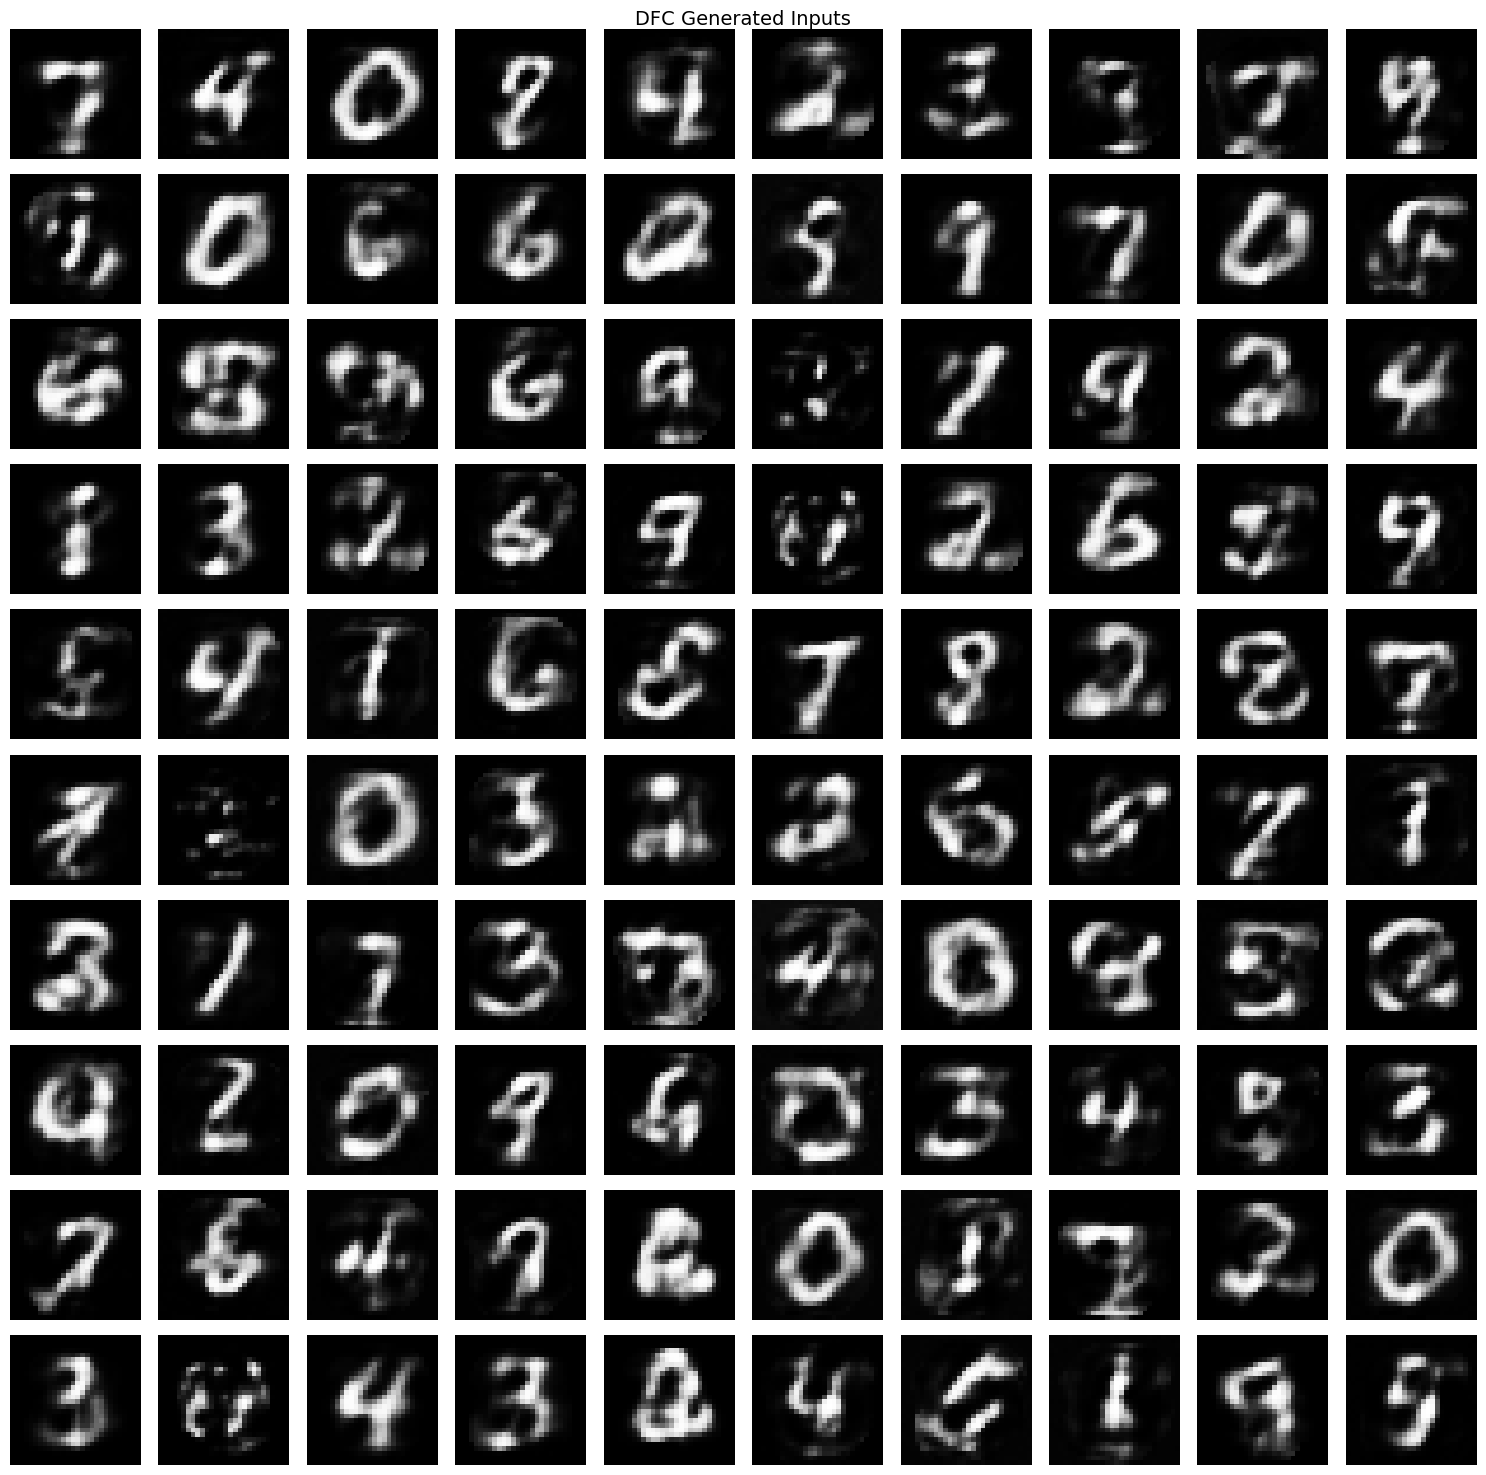

In [100]:
plot_generated_inputs(generated_input2[:100], n_cols=10, title="DFC Generated Inputs", save=False, filename="Samples_BP_100_epochs.png")

In [101]:
for i in range(10):
    print(i)
    print(Y_label[10*i:(10*i+10)])
    print(target.argmax(dim=1)[10*i:(10*i+10)])
    #print((model.layers[0].activation_fn(generated_input2@model.layers[0].weights.t())@model.layers[1].weights.t()).argmax(dim=1)[10*i:(10*i+10)])


0
tensor([3, 5, 9, 7, 7, 9, 1, 3, 3, 2])
tensor([7, 4, 0, 8, 4, 2, 3, 9, 7, 9], device='cuda:0')
1
tensor([5, 4, 9, 1, 0, 5, 1, 1, 4, 2])
tensor([1, 0, 6, 6, 2, 9, 9, 7, 0, 5], device='cuda:0')
2
tensor([4, 4, 6, 8, 2, 4, 1, 2, 4, 1])
tensor([6, 5, 7, 6, 9, 1, 7, 9, 2, 4], device='cuda:0')
3
tensor([1, 1, 4, 0, 5, 8, 7, 5, 7, 2])
tensor([8, 3, 2, 6, 9, 4, 2, 6, 5, 9], device='cuda:0')
4
tensor([8, 7, 7, 2, 8, 8, 9, 4, 5, 0])
tensor([5, 4, 1, 6, 5, 7, 8, 2, 8, 7], device='cuda:0')
5
tensor([4, 6, 9, 8, 1, 6, 5, 0, 4, 7])
tensor([9, 1, 0, 3, 2, 2, 6, 5, 7, 1], device='cuda:0')
6
tensor([5, 1, 8, 6, 8, 7, 8, 4, 3, 0])
tensor([2, 7, 7, 3, 7, 4, 0, 8, 5, 2], device='cuda:0')
7
tensor([9, 2, 2, 4, 2, 2, 4, 2, 8, 9])
tensor([4, 1, 0, 9, 6, 0, 3, 4, 5, 3], device='cuda:0')
8
tensor([2, 8, 1, 8, 6, 8, 8, 2, 9, 9])
tensor([7, 6, 4, 9, 2, 0, 1, 7, 2, 0], device='cuda:0')
9
tensor([1, 8, 1, 1, 0, 6, 6, 6, 5, 0])
tensor([3, 4, 4, 3, 2, 4, 5, 1, 9, 5], device='cuda:0')


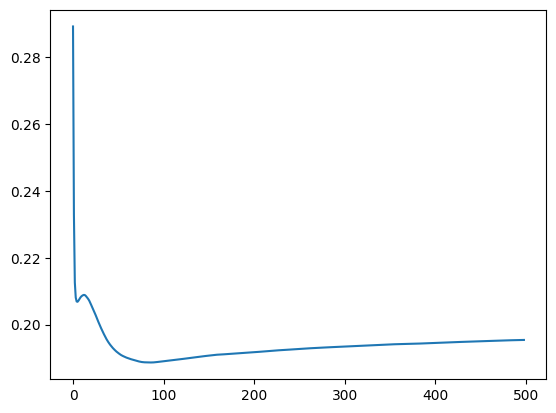

In [139]:
plt.plot(diffs)
#plt.axvline(x=1400, color='red', linestyle='--')
#plt.xlim([0,100])
plt.show()

In [363]:
y_hat = model(X.to(device=model.device))
diff = torch.abs( model.layers[0].activation_fn(model.layers[0](generated_input2)) - model.layers[0].r).mean().detach().cpu().numpy()
print(diff)

0.12164751


In [ ]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import umap
import numpy as np
from tqdm import tqdm

# --- 1. Load MNIST ---
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # flatten 28x28 -> 784
])
mnist_train = datasets.MNIST(root="./data", train=True, transform=transform, download=True)

# Convert entire dataset to tensors
X = torch.stack([mnist_train[i][0] for i in tqdm(range(len(mnist_train)), desc="Loading MNIST")])
y = torch.tensor([mnist_train[i][1] for i in range(len(mnist_train))])

print(f"Data shape: {X.shape}, Labels shape: {y.shape}")  # Expect (60000, 784)

# --- 2. (Optional) Normalize ---

# --- 3. Run UMAP ---
reducer = umap.UMAP(
    n_neighbors=30,       # local neighborhood size
    min_dist=0.1,         # controls clustering tightness
    n_components=2,       # 2D projection
    metric='euclidean',   # distance metric
    random_state=42
)

embedding = reducer.fit_transform(X.numpy())

print("UMAP embedding shape:", embedding.shape)

# --- 4. Plot ---
plt.figure(figsize=(8, 8))
scatter = plt.scatter(embedding[:, 0], embedding[:, 1], c=y.cpu(), cmap="Spectral", s=2, alpha=0.6)
plt.colorbar(scatter, boundaries=np.arange(11)-0.5, ticks=np.arange(10))
plt.title("UMAP projection of MNIST (60k training samples)", fontsize=12)
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.grid(True, alpha=0.3)
plt.show()



In [27]:
import joblib
np.save("mnist_umap_embedding_hidden.npy", embedding)
joblib.dump(reducer, "umap_model_hidden.pkl")

In [25]:
import joblib
from tqdm import tqdm


# --- 1. Load MNIST ---
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # flatten 28x28 -> 784
])
mnist_train = datasets.MNIST(root="./data", train=True, transform=transform, download=True)

# Convert entire dataset to tensors
X = torch.stack([mnist_train[i][0] for i in tqdm(range(len(mnist_train)), desc="Loading MNIST")])
y = torch.tensor([mnist_train[i][1] for i in range(len(mnist_train))])

# Load UMAP model
reducer = joblib.load("umap_model.pkl")

# Load embedding
embedding = np.load("mnist_umap_embedding.npy")

Loading MNIST:   0%|          | 0/60000 [00:00<?, ?it/s]

Loading MNIST: 100%|██████████| 60000/60000 [00:06<00:00, 9242.12it/s]


Generated embedding shape: (60000, 2)


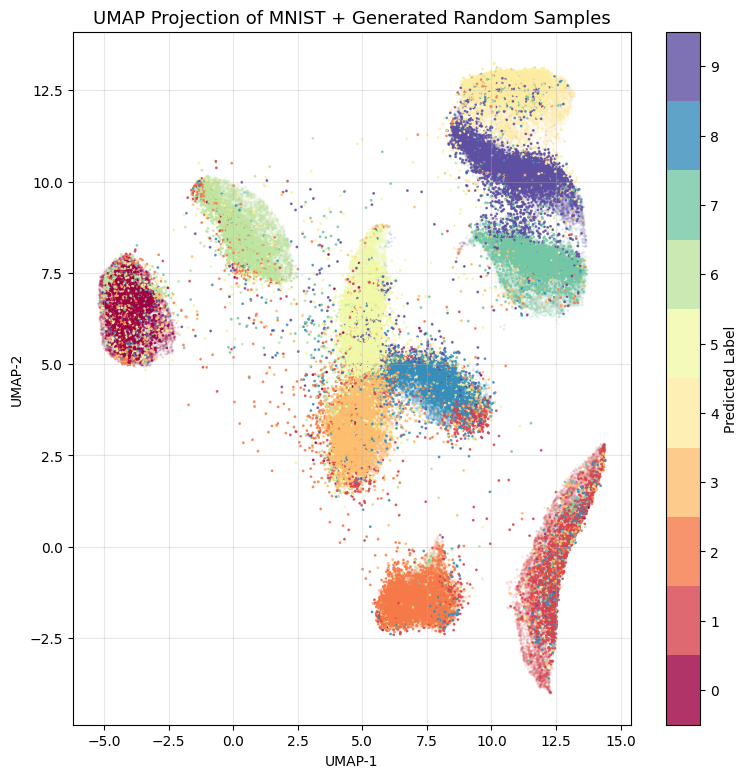

In [26]:
x_final = generated_input.clone().detach().cpu()
sm = torch.nn.Softmax(dim=1)
#y_hat = sm(rs[-1])
y_hat = sm(model(generated_input))
y_labels = torch.argmax(y_hat, dim=1)

embedding_gen = reducer.transform(x_final.numpy())
print("Generated embedding shape:", embedding_gen.shape)

# --- Plot ---
plt.figure(figsize=(9, 9))

# Plot MNIST samples
scatter_mnist = plt.scatter(
    embedding[:, 0], embedding[:, 1],
    c=y.cpu(), cmap="Spectral", s=1, alpha=0.1, label="MNIST"
)

# Plot generated samples
scatter_gen = plt.scatter(
    embedding_gen[:, 0], embedding_gen[:, 1],
    c=y_labels.cpu(), cmap="Spectral", s=1, alpha=0.8, label="Generated"
)

plt.title("UMAP Projection of MNIST + Generated Random Samples", fontsize=13)
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.grid(True, alpha=0.3)

# Choose which scatter to colorbar — here, the generated one
cbar = plt.colorbar(scatter_gen, boundaries=np.arange(11)-0.5, ticks=np.arange(10))
cbar.set_label("Predicted Label")

plt.show()


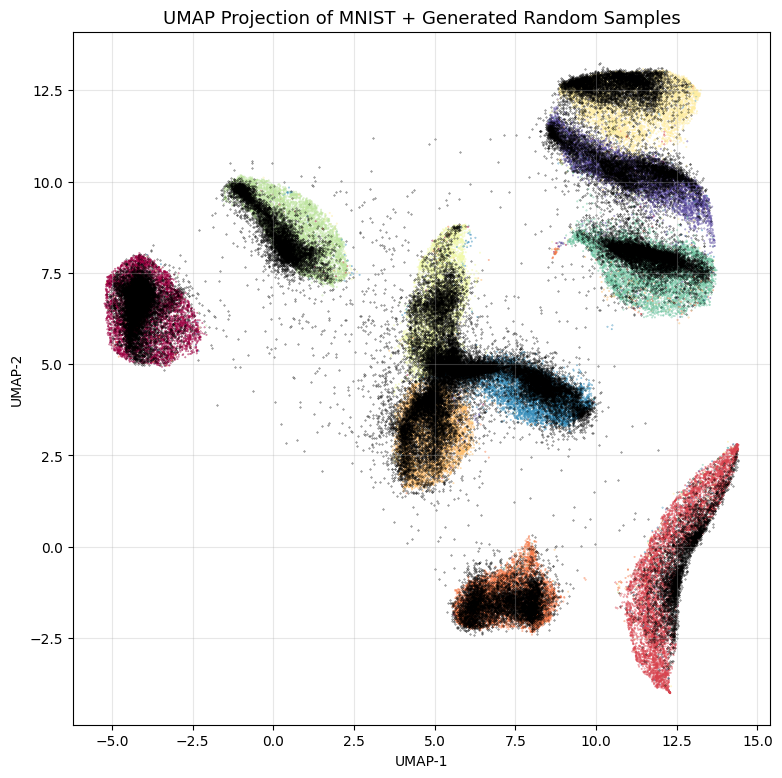

In [ ]:
# --- Plot ---
plt.figure(figsize=(9, 9))

# Plot MNIST samples
scatter_mnist = plt.scatter(
    embedding[:, 0], embedding[:, 1],
    c=y.cpu(), cmap="Spectral", s=0.1, alpha=0.8, label="MNIST"
)

# Plot generated samples
scatter_gen = plt.scatter(
    embedding_gen[:, 0], embedding_gen[:, 1],
    c="black", s=0.1, alpha=0.8, label="Generated"
)

plt.title("UMAP Projection of MNIST + Generated Random Samples", fontsize=13)
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.grid(True, alpha=0.3)

# Choose which scatter to colorbar — here, the generated one
cbar.set_label("Predicted Label")

plt.show()


In [28]:
from torch.utils.data import TensorDataset, ConcatDataset, DataLoader
from torchvision import datasets, transforms

sm = torch.nn.Softmax(dim=1)

x_gen =  generated_input.clone().detach().cpu()
#y_hat = sm(rs[-1]) 
y_hat = (sm(model(generated_input)).clone().detach())#.argmax(dim=1)
#y_hat = F.one_hot(y_hat, num_classes=10).float()
#y_hat = target.float()

generated_dataset1 = TensorDataset(x_gen, y_hat)

# Original MNIST
"""from torchvision.datasets import MNIST
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])

mnist_train = datasets.MNIST(root="./data", train=True, download=True, transform=transform, target_transform=lambda y: F.one_hot(torch.tensor(y), num_classes=10).float())"""

# Combine them
full_dataset = ConcatDataset([generated_dataset1])

# Build dataloader
g = torch.Generator(device="cuda")
g.manual_seed(42)

train_loader2 = DataLoader(
    full_dataset,
    batch_size=100,
    shuffle=True,
    generator=g
)


In [ ]:
# Train model
config2 = config.copy()
config2["epochs"] = 50
config2["loss_fn"] = "ce"
config2["save"] = False
config2 = dotdict(config2)
model2 = BP_network(config=config2)

"""trainer2 = Trainer(model2, train_loader, test_loader, config)
trainer2.train()"""
trainer3 = Trainer(model2, train_loader2, test_loader, config2)
trainer3.train()


Training:
 - layers: [784, 200, 10]
 - num_classes: 10
 - lr: 0.0001
 - lr_fb: 0.0001
 - batch_size: 100
 - batch_size_gen: 30000
 - epochs: 50
 - mode: di
 - num_workers: 0
 - loss_fn: ce
 - optimizer: Adam
 - scheduler: CosineAnnealingLR
 - activation_fun: Tanh
 - device: cuda
 - output_dir: ./outputs
 - seed: 1337
 - taus: [0.02, 0.02, 0.02, 0.016, 0.01]
 - target_lr: 1
 - alpha_di: 0.0017
 - dt_di: 0.02
 - time_constant_ratio: 0.2
 - tmax_di: 100
 - k_p: 2.0
 - eps: 0.0001
 - save: False
 - flatten_imgs: default
 - num_tasks: 2
 - classes_per_task: 5
 - setting: full
 - first_task_only: False
 - in_channels: 1
 - model: BP_network



				Epoch: 001, Train loss: 0.5181 & test loss: 0.4618 & accuracy: 86.85


				Epoch: 002, Train loss: 0.2994 & test loss: 0.3849 & accuracy: 88.85


				Epoch: 003, Train loss: 0.2794 & test loss: 0.3481 & accuracy: 89.81


				Epoch: 004, Train loss: 0.2699 & test loss: 0.3337 & accuracy: 90.03


...

				Epoch: 046, Train loss: 0.2370 & test loss: 0.2157 & accuracy: 93.46


				Epoch: 047, Train loss: 0.2369 & test loss: 0.2169 & accuracy: 93.42


				Epoch: 048, Train loss: 0.2367 & test loss: 0.2140 & accuracy: 93.57


				Epoch: 049, Train loss: 0.2367 & test loss: 0.2154 & accuracy: 93.49


				Epoch: 050, Train loss: 0.2366 & test loss: 0.2142 & accuracy: 93.50


In [317]:
(train_loss, train_acc), (test_loss, test_acc) = evaluate(model2, train_loader, test_loader, device=model.device)

Train loss: 0.0991 | Train acc: 97.06%
Test  loss: 0.1144 | Test  acc: 96.55%


In [32]:
X_mc = []
X_cc = []

for X, y in test_loader:
    X = X.to(model2.device)
    y = y.to(model2.device)

    y_hat = model2(X)
    X_mc.append(X[y_hat.argmax(dim=1) != y.argmax(dim=1)])
    X_cc.append(X[y_hat.argmax(dim=1) == y.argmax(dim=1)])

X_mistakes = torch.cat(X_mc, dim=0)
X_correct = torch.cat(X_cc, dim=0)


In [103]:
y_hat = (rs[-2]@model.layers[1].weights.t()).argmax(dim=1)
y_true = rs[-1].argmax(dim=1)
print((y_hat==y_true).sum())

tensor(60000, device='cuda:0')


In [104]:
y_hat = (model.layers[0].activation_fn(generated_input2@model.layers[0].weights.t())@model.layers[1].weights.t()).argmax(dim=1)
y_true = rs[-1].argmax(dim=1)
print((y_hat==y_true).sum())

tensor(56958, device='cuda:0')


In [ ]:
"""#_ = model(X_mistakes)
#embedding_test = reducer.transform(model.layers[0].r.detach().cpu().numpy())
embedding_test = reducer.transform(X_mistakes.detach().cpu().numpy())

#_ = model(X_correct)
#embedding_test2 = reducer.transform(model.layers[0].r.detach().cpu().numpy())
embedding_test2 = reducer.transform(X_correct.detach().cpu().numpy())"""

# --- Plot ---
plt.figure(figsize=(9, 9))

# Plot MNIST samples
"""scatter_mnist = plt.scatter(
    embedding[:, 0], embedding[:, 1],
    c=y.cpu(), cmap="Spectral", s=0.1, alpha=0.8, label="MNIST"
)"""

# Plot test errors
scatter_gen = plt.scatter(
    embedding_test[:, 0], embedding_test[:, 1],
    c="red", s=1, alpha=0.8, label="test errors"
)

scatter_gen2 = plt.scatter(
    embedding_test2[:, 0], embedding_test2[:, 1],
    c="green", s=1, alpha=0.8, label="test correct"
)

#plt.title("UMAP Projection of MNIST + Generated Random Samples", fontsize=13)
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.grid(True, alpha=0.3)

# Choose which scatter to colorbar — here, the generated one
#cbar.set_label("Predicted Label")

plt.show()


In [ ]:
config2 = config.copy()
config2["epochs"] = 100
config2["tmax_di"] = 2
config2["target_lr"] = 1#0.01
config2["eps"] = 1e-4
config2 = dotdict(config2)

model2 = DFCL_network(config=config2)

trainer3 = TrainerDFCL(model2, train_loader2, test_loader, config2)
trainer3.train()

In [ ]:

mask = (

    (embedding_test2[:, 0] >= 10) & (embedding_test2[:, 0] <= 13) &
    (embedding_test2[:, 1] >= 2) & (embedding_test2[:, 1] <= 5)
)

indices = np.where(mask)[0]

for i in range(20):
    plt.imshow(X_correct.cpu()[indices[i]].reshape(28,28))
    plt.show()

In [ ]:
import torch
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from openTSNE import TSNEEmbedding, affinity, initialization

# --- 1. Load MNIST ---
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # flatten 28x28 -> 784
])
mnist_train = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
mnist_test = datasets.MNIST(root="./data", train=False, transform=transform, download=True)

# Convert to tensors
X_train = torch.stack([mnist_train[i][0] for i in range(len(mnist_train))]).numpy()
y_train = np.array([mnist_train[i][1] for i in range(len(mnist_train))])
X_test = torch.stack([mnist_test[i][0] for i in range(len(mnist_test))]).numpy()
y_test = np.array([mnist_test[i][1] for i in range(len(mnist_test))])

print("Train:", X_train.shape, "Test:", X_test.shape)

# Optional normalization
X_train = X_train / X_train.max()
X_test = X_test / X_test.max()

# --- 2. Fit t-SNE on training data ---
aff = affinity.PerplexityBasedNN(
    X_train, perplexity=30, metric="euclidean", n_jobs=8, random_state=42
)

init = initialization.pca(X_train, n_components=2, random_state=42)

embedding = TSNEEmbedding(init, aff, n_jobs=8, random_state=42)

# Optimization (two phases: early exaggeration + refinement)
embedding = embedding.optimize(n_iter=250, exaggeration=12, momentum=0.5, inplace=True)
embedding = embedding.optimize(n_iter=750, momentum=0.8, inplace=True)

print("Training embedding shape:", embedding.shape)


In [ ]:
# --- 4. Plot ---
plt.figure(figsize=(8, 8))
sc_embedding = plt.scatter(embedding[:, 0], embedding[:, 1], c=y_train, cmap="Spectral", s=2, alpha=0.1, label="Train")
vid_embedding = plt.scatter(generated_input_embedding[:, 0], generated_input_embedding[:, 1], c="black", s=1, alpha=0.8, label="Video")
#vid_embedding = plt.scatter(generated_input_embedding[:, 0], generated_input_embedding[:, 1], c=rs[-1].argmax(dim=1).cpu(), cmap="Spectral", s=1, alpha=0.8, label="Video")


plt.title("MNIST train T-SNE embedding + transformed generated data")
plt.xlabel("t-SNE-1")
plt.ylabel("t-SNE-2")
cb = plt.colorbar(sc_embedding, boundaries=np.arange(11)-0.5, ticks=np.arange(10))
cb.solids.set_alpha(1)     # make colorbar fully opaque
plt.show()

In [ ]:

# --- 1. Create figure ---
fig = plt.figure(figsize=(8, 8))

# --- 2. Static t-SNE background (MNIST samples) ---
scatter_tsne = plt.scatter(
    embedding[:, 0], embedding[:, 1],
    c=y_train, cmap="Spectral", s=2, alpha=0.1, label="Train"
)

# --- 3. Dynamic overlay (video/generated samples) ---
#      Assuming video_embedding is shaped (num_frames, N, 2)
im = plt.scatter(
    video_embedding[0][0], video_embedding[0][1],
    c="black", s=6, alpha=0.8, label="Video"
)

plt.title("t-SNE embedding during contrastive sample generation", fontsize=13)
plt.xlabel("t-SNE-1")
plt.ylabel("t-SNE-2")
plt.grid(True, alpha=0.3)

# --- 4. Colorbar ---
cb = plt.colorbar(scatter_tsne, boundaries=np.arange(11) - 0.5, ticks=np.arange(10))
cb.solids.set_alpha(1)  # make colorbar fully opaque

# Optional: legend

# --- 5. Update function for animation ---
def update(i):
    im.set_offsets(video_embedding[i])  # expects shape (N, 2)
    return [im]

# --- 6. Create animation ---
ani = animation.FuncAnimation(
    fig, update, frames=200, interval=50, blit=True
)

plt.show()


In [ ]:
video_tsne = torch.stack(video).cpu()
video_embedding = embedding.transform(video_tsne, perplexity=30)

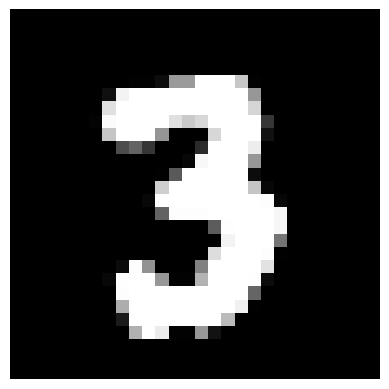

In [102]:
from matplotlib import animation
video = video[:converged_time[0].item()]

fig = plt.figure()
im = plt.imshow(video[0].cpu().reshape(28,28),cmap="grey")
plt.axis("off")

def update(i):
    if i>=converged_time[0].item():
        index = -(i-converged_time[0].item()+1)
    else:
        index = i
    im.set_array(video[index].cpu().reshape(28,28))
    return [im]

ani = animation.FuncAnimation(fig, update, frames=converged_time[0].item()*2, interval=50)


In [103]:

ani.save('morphing_animations/3-7-3.gif', writer='pillow', fps=5)

Animation.save using <class 'matplotlib.animation.PillowWriter'>


In [56]:
print(converged_time[0])

tensor(0, device='cuda:0')
